PROGRAMMA IN CUI FACCIO  lettura dati SED e trasformazione da nuFnu a nuLnu, calcolo disco SS e plot SED + disco

In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

# 0) INPUT
sed_filename = "3FGLJ0133.25159.txt"
source_name = "3FGLJ0133.2-5159"
csv_filename = "Tabella_Completa.csv"
csv_file_key = "ZBLLAC_3FGL_J0133.2-5159_10_spectrum.txt"

# Parametri disco e costanti : come nel programma disco.ipynb
c = 2.99792458e10
G = 6.67430e-8
h = 6.62607015e-27
kB = 1.380649e-16
sigma = 5.670374419e-5
Msun = 1.98847e33

MBH_msun = 1e8
eta = 0.083
Ldisk_over_Ledd = 0.1
Nr = 2000
Nnu_disk = 800
nu_disk = np.logspace(13, 17, Nnu_disk)  # Hz 

MBH = MBH_msun * Msun
Ledd = 1.3e38 * (MBH / Msun)                 # erg/s
Ldisk = Ldisk_over_Ledd * Ledd               # erg/s
Mdot = Ldisk / (eta * c**2)                  # g/s

Rs = 2 * G * MBH / c**2
Rin = 3 * Rs
Rout = 3000 * Rs
R = np.logspace(np.log10(Rin), np.log10(Rout), Nr)

In [136]:
# 1) Leggo redshift dal file di Gabriele !!!!!!
df = pd.read_csv(csv_filename)
sel = df.loc[df["file_name"] == csv_file_key]
if len(sel) == 0:
    raise ValueError(f"Non trovo '{csv_file_key}' nella colonna file_name del CSV.")
row = sel.iloc[0] 
z = float(row["redshift"])
print(f"Redshift z = {z}")

# 2) Distanza di luminosità dL (Flat LCDM, H0=70, Om=0.3) dato che SSDC fornisce nuFnu in erg cm^-2 s^-1
c_kms = 2.99792458e5
Mpc_to_cm = 3.085677581e24

def dL_cm_flatLCDM(z, H0=70.0, Om=0.3):  #calcolo la distanza di luminosità in cm cosicché posso convertire dopo nuFnu in nuLnu
    Ol = 1.0 - Om
    zz = np.linspace(0, z, 8000)
    Ez = np.sqrt(Om*(1+zz)**3 + Ol)
    Dc_Mpc = (c_kms/H0) * np.trapezoid(1.0/Ez, zz)
    dL_Mpc = (1+z) * Dc_Mpc
    return dL_Mpc * Mpc_to_cm
dL_cm = dL_cm_flatLCDM(z)
print(f"dL = {dL_cm:.3e} cm")

# 3) Leggo file SED SSDC:  freq = colonna 0,  nuFnu = colonna 2,  err   = colonna 3,  telescopio dai commenti "# ... (id = ...)"
data = []
current_telescope = None

with open(sed_filename, "r") as f:  
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith("#"):
            if "id =" in line:
                current_telescope = line.strip("# ").split(" (id")[0].strip()
            continue
        parts = line.split()
        if len(parts) >= 6 and current_telescope is not None:
            try:
                freq = float(parts[0])      # Hz
                nuFnu = float(parts[2])     # erg cm^-2 s^-1
                nuFnu_err = float(parts[3]) # erg cm^-2 s^-1    
                data.append({
                    "nu": freq,
                    "nuFnu": nuFnu,
                    "nuFnu_err": nuFnu_err,
                    "Telescope": current_telescope})
            except ValueError:
                continue

sed = pd.DataFrame(data)
if sed.empty:
    raise ValueError("Nessun dato letto dal file SED: controlla formato/colonne.")

# pulizia
sed = sed[(sed["nu"] > 0) & (sed["nuFnu"] > 0)].copy()    # filtro frequenze e nuFnu non positive
sed.loc[sed["nuFnu_err"] <= 0, "nuFnu_err"] = sed["nuFnu"] * 0.05     # errore 5% per nuFnu negativo

# 4) Conversione: nuFnu -> nuLnu
sed["nuLnu"] = 4.0 * np.pi * dL_cm**2 * sed["nuFnu"]
sed["nuLnu_err"] = 4.0 * np.pi * dL_cm**2 * sed["nuFnu_err"]

sed["log_nu"] = np.log10(sed["nu"])
sed["log_nuLnu"] = np.log10(sed["nuLnu"])
sed["log_nuLnu_err"] = sed["nuLnu_err"] / (sed["nuLnu"] * np.log(10))  # errore logaritmico è dato da delta(nuLnu) / (nuLnu * ln(10)) perchè log10(x) ha derivata 1/(x ln(10))
#sed["log_nuLnu_err"] = sed["log_nuLnu_err"].clip(upper=1.0)  #taglio errore a 1 decimale per evitare problemi di visualizzazione

sed = sed.replace([np.inf, -np.inf], np.nan).dropna(subset=["log_nu", "log_nuLnu", "log_nuLnu_err"])

print("Telescopi trovati:", sed["Telescope"].nunique())  #numero di telescopi letti 

Redshift z = 0.925
dL = 1.852e+28 cm
Telescopi trovati: 18


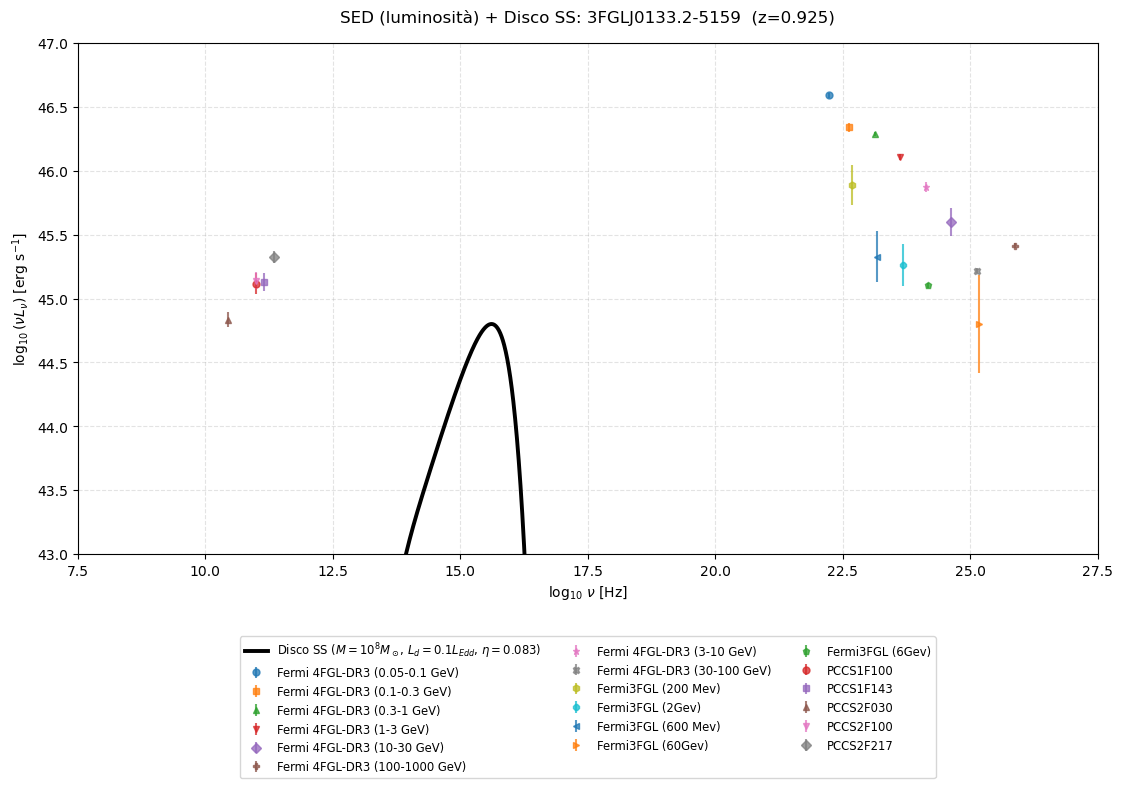

In [137]:
# 5) Disco Sakura-Sunyaev: calcolo nuLnu come in disco.ipynb
f = 1.0 - np.sqrt(Rin / R)
f = np.clip(f, 0.0, None)
T = ((3*G*MBH*Mdot)/(8*np.pi*sigma*R**3) * f)**0.25

# Planck + integrazione su R
Bnu = np.zeros((len(nu_disk), len(R)))
for j in range(len(R)):
    x = np.clip(h * nu_disk / (kB * T[j]), 1e-12, 700.0)
    Bnu[:, j] = (2*h*nu_disk**3 / c**2) / (np.exp(x) - 1.0)
I_nu = np.trapezoid(R[None, :] * Bnu, R, axis=1)
Lnu_disk = 4 * np.pi**2 * I_nu
nuLnu_disk = nu_disk * Lnu_disk

# 6) Plot: SED in luminosità + curva emissione disco
marker_cycle = itertools.cycle(['o','s','^','v','D','P','*','X','h','8','<','>','p']) 
fig, ax = plt.subplots(figsize=(12, 7))

# dati SED
for telescope, group in sed.groupby("Telescope"):
    m = next(marker_cycle)
    ax.errorbar(   
        group["log_nu"], group["log_nuLnu"],
        yerr=group["log_nuLnu_err"],       
        fmt=m, markersize=5, alpha=0.75,
        linestyle="None", label=telescope)

# disco
ax.plot(np.log10(nu_disk), np.log10(nuLnu_disk),lw=2.8, color="k", label=rf"Disco SS ($M=10^8M_\odot$, $L_d=0.1L_{{Edd}}$, $\eta={eta}$)")
ax.set_xlabel(r'$\log_{10}\,\nu$ [Hz]')
ax.set_ylabel(r'$\log_{10}(\nu L_\nu)$ [erg s$^{-1}$]')
ax.set_title(f"SED (luminosità) + Disco SS: {source_name}  (z={z:.3f})", pad=15)
ax.grid(True, which="both", ls="--", alpha=0.35)
ax.set_xlim(7.5, 27.5)
ax.set_ylim(43, 47)
leg = ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize='small', frameon=True)
fig.subplots_adjust(bottom=0.22, top=0.95, left=0.1, right=0.95)

plt.show()

COSE DA FARE: 

OPZIONALE: pensare a quella cosa dell'introduzione 

DOMANDE IRRISOLTE: 
0) sono ok le energie potenziali di Hg e Hd? le ho trovate su internet perchè c'erano nella tab completa di Gabriele, ma non nel file del calcolo delle nu_ion
a) devo mettere massa e raggi diversi per ciascun blazar nel programma del modello del disco (disco.ipynb)? che poi uso per confrontare Lion (ottenuto integrando L del programma tra nu_ion e nu_max) teorico della riga di quella definita trans con Llinea ottenuta da Gabriele  (corretto no?)
b) devo confrontare Lblr=sommatoria (Llinee) con Ldisk (del programma disco.ipynb ottenuto già dai dati) ?
c) a cosa mi servono quantitativamente le SED ? Non ho già tutto da programma emissione disco e dalle linee di Gabriele ? Trovo dei parametri (masse e raggi) da lì?
d) cosa succede se non ho nessun dato o quasi nelle sed ? EX 3FGLJ0021.6-6835
f) cosa succede e cosa vuol dire se non ho dati nella regione centrale che è dove c'è disco? come si riflette sulla mia ricerca. è problema e lo posso risolvere in qualche modo ? Oppure ne prendo soltanto atto e lo faccio notare qualitativamente?
g) il covering factor lo fisso oppure lo devo ottenere e lo analizzo dopo?
h) è ok il calcolo delle L dai flussi in programma sed.ipynb? perchè dati da ssdc erano in flussi  quindi ho convertito 
i) disco molto più sotto a sed, inoltre posso ricavare qualche cosa da questo grafico ?

In [138]:
import pandas as pd
import numpy as np
import itertools
filename = '3FGLJ0133.25159.txt'
source_name = "Blazar 3FGLJ0133.25159"

In [139]:
data = []
current_telescope = None

with open(filename, 'r') as f:
    for line in f:
        line = line.strip()
        if line.startswith('#'):
            if 'id =' in line:
                # Estrae il nome del telescopio
                current_telescope = line.strip('# ').split(' (id')[0]
        elif line:
            parts = line.split()
            if len(parts) >= 6 and current_telescope:
                try:
                    freq = float(parts[0])
                    flux = float(parts[2])
                    flux_err = float(parts[3])
                    data.append({
                        'Freq': freq,
                        'Flux': flux,
                        'Flux_err': flux_err,
                        'Telescope': current_telescope
                    })
                except ValueError:
                    continue

sed_data = pd.DataFrame(data)
# Controlla il contenuto
# print(sed_data.head())
# print(sed_data['Telescope'].unique())

In [140]:
sed_data_valid = sed_data[(sed_data['Flux'] > 0) & (sed_data['Freq'] > 0)].copy()
sed_data_valid.loc[sed_data_valid['Flux_err'] == 0, 'Flux_err'] = sed_data_valid['Flux'] * 0.05
# Calcola log(Freq), log(Flux) e log(errore)
sed_data_valid['log_Freq'] = np.log10(sed_data_valid['Freq'])
sed_data_valid['log_Flux'] = np.log10(sed_data_valid['Flux'])
sed_data_valid['log_Flux_err'] = sed_data_valid['Flux_err'] / (sed_data_valid['Flux'] * np.log(10))
sed_data_valid['log_Flux_err'] = sed_data_valid['log_Flux_err'].clip(upper=1.0)
# Rimuove eventuali inf/NaN residui
sed_data_valid = sed_data_valid.replace([np.inf, -np.inf], np.nan).dropna(subset=['log_Freq', 'log_Flux', 'log_Flux_err'])


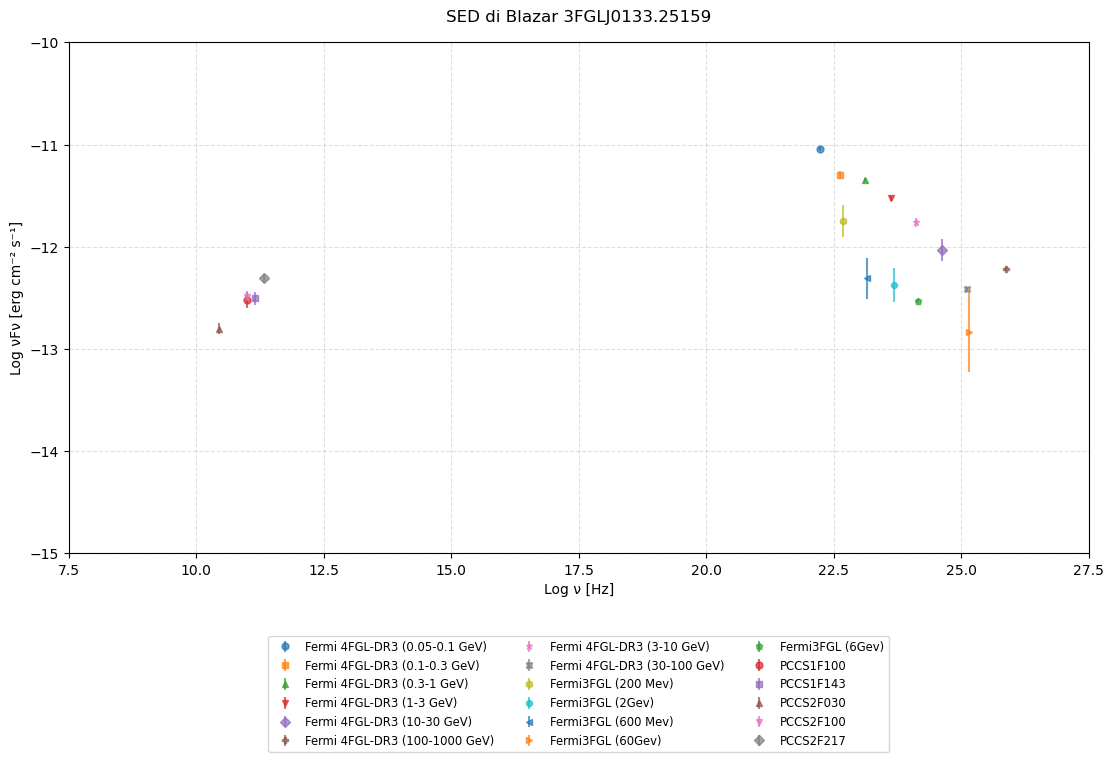

In [141]:
import matplotlib.pyplot as plt
import itertools

marker_cycle = itertools.cycle(['o','s','^','v','D','P','*','X','h','8','<','>','p'])
fig, ax = plt.subplots(figsize=(12, 7))

# 1) Plot dei dati
for telescope, group in sed_data_valid.groupby('Telescope'):
    m = next(marker_cycle)
    ax.errorbar(
        group['log_Freq'], group['log_Flux'],
        yerr=group['log_Flux_err'],
        fmt=m, markersize=5, alpha=0.7,
        linestyle='None', label=telescope
    )

# 2) Etichette, titolo e griglia
ax.set_xlabel('Log ν [Hz]')
ax.set_ylabel('Log νFν [erg cm⁻² s⁻¹]')
ax.set_title(f"SED di {source_name}", pad=15)
ax.grid(True, which='both', ls='--', alpha=0.4)
ax.set_xlim(7.5, 27.5)
ax.set_ylim(-15, -10)

# 3) Legenda in basso, 3 colonne
leg = ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,              # <-- TRE colonne
    fontsize='small',
    frameon=True
)

# 4) Regola i margini per far spazio alla legenda
fig.subplots_adjust(bottom=0.22, top=0.95, left=0.1, right=0.95)

plt.show()

In [142]:
!pip install agnpy

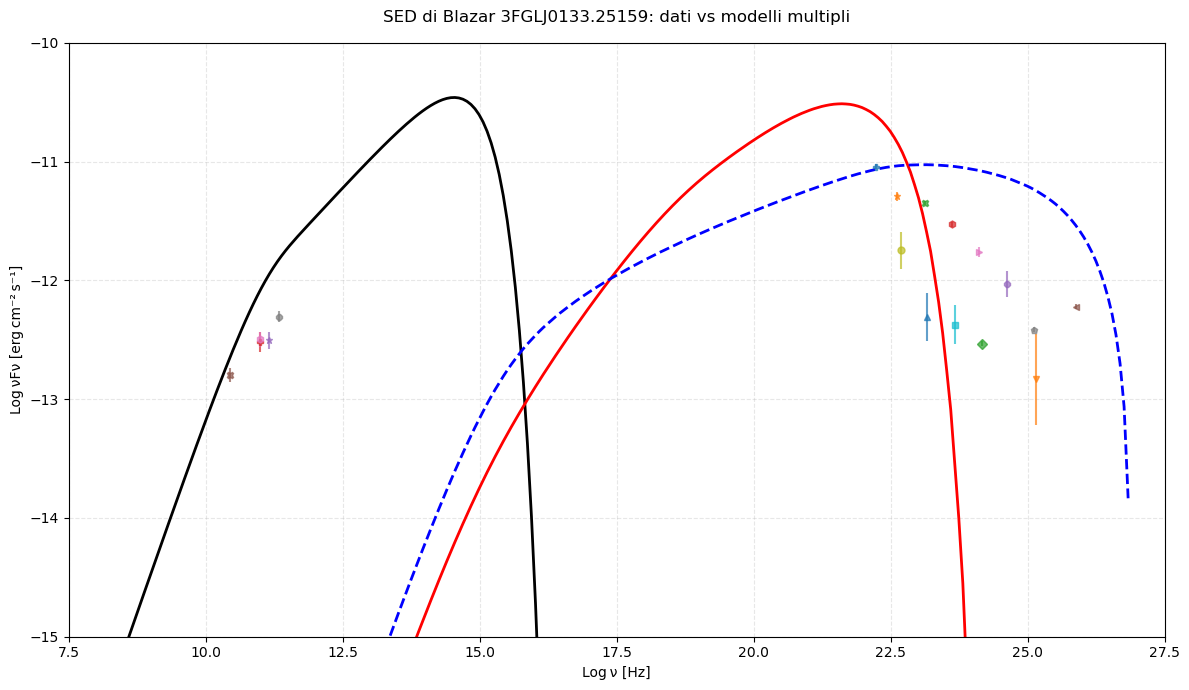

In [143]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.constants import m_e, m_p
from astropy.coordinates import Distance
from agnpy.spectra import PowerLaw
from agnpy.emission_regions import Blob
from agnpy.synchrotron import Synchrotron
from agnpy.compton import SynchrotronSelfCompton

# --- 1) Parametri generali e sorgente --- #49, B=0.3


R_b    =3.1e16 * u.cm    # raggio del blob  #se aqumento Rbcurva rossa scende
deltaD = 10               # Doppler factor
Gamma  = 19               # bulk Lorentz factor
B      = 0.85 * u.G        # campo magnetico
z      = 0.3365            # redshift
d_L    = Distance(z=z).to(u.cm)
V_b    = (4/3) * np.pi * R_b**3


# --- 2) Blob elettronico (Synch + SSC leptonic) ---
W_e = 0.5e49 * u.erg
n_e = PowerLaw.from_total_energy(
    W=W_e, V=V_b, p=2,
    gamma_min=0.6e2, gamma_max=0.6e4,
    mass=m_e
)
blob_e = Blob(R_b, z, deltaD, Gamma, B, n_e)

# --- 3) Blob protonico (SSC hadronic) ---
W_p = 0.95e52 * u.erg
n_p = PowerLaw.from_total_energy(
    W=W_p, V=V_b, p=2.8,
    gamma_min=0.7e2, gamma_max=8.2e5,
    mass=m_p
)
blob_p = Blob(R_b, z, deltaD, Gamma, B, n_p)

# --- 4) Griglia di frequenze comune ---
nu = np.logspace(8, 30, 300) * u.Hz

# --- 5) Calcolo delle SED teoriche ---
sed_syn   = Synchrotron(blob_e).sed_flux(nu)
sed_ssc   = SynchrotronSelfCompton(blob_e).sed_flux(nu)
sed_ssc_p = SynchrotronSelfCompton(blob_p).sed_flux(nu)  # SSC hadronic

# --- 6) Plot combinato dati + modelli ---
fig, ax = plt.subplots(figsize=(12, 7))

# 6a) dati osservati
for tel, grp in sed_data_valid.groupby('Telescope'):
    m = next(marker_cycle)
    ax.errorbar(
        grp['log_Freq'], grp['log_Flux'],
        yerr=grp['log_Flux_err'],
        fmt=m, ms=5, alpha=0.7,
        linestyle='None', label=tel
    )

# 6b) maschere di positività
mask_syn = sed_syn.value   > 0
mask_lep = sed_ssc.value   > 0
mask_had = sed_ssc_p.value > 0

# 6c) curve teoriche (in log10)
ax.plot(np.log10(nu[mask_syn].value),
        np.log10(sed_syn[mask_syn].value),
        '-', lw=2, color='k', label='Synchrotron (e⁻)')

ax.plot(np.log10(nu[mask_lep].value),
        np.log10(sed_ssc[mask_lep].value),
        '-', lw=2, color='r', label='SSC (leptonic)')

ax.plot(np.log10(nu[mask_had].value),
        np.log10(sed_ssc_p[mask_had].value),
        '--', lw=2, color='b', label='SSC (hadronic)')



# 6d) abbellimenti
ax.set_xlabel('Log ν [Hz]')
ax.set_ylabel('Log νFν [erg cm⁻² s⁻¹]')
ax.set_title(f'SED di {source_name}: dati vs modelli multipli', pad=15)

ax.grid(True, which='both', ls='--', alpha=0.3)
ax.set_xlim(7.5, 27.5)
ax.set_ylim(-15, -10)
"""
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3, fontsize='small', frameon=True
)
"""
fig.subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.show()


In [144]:

from agnpy.targets import SSDisk
import astropy.units as u
from astropy.constants import M_sun

# Parametri richiesti
#M_BH = 1e8 * M_sun  # Massa del buco nero
#L_disk = 1e45 * u.erg / u.s  # Luminosità del disco
#eta = 1 / 12  # Efficienza di accrescimento
#R_in = 6  # Raggio interno in unità di R_g
#R_out = 200  # Raggio esterno in unità di R_g

M_BH = 1e8 * M_sun  # Massa del buco nero
L_disk = 1e44 * u.erg / u.s  # Luminosità del disco   #regola altezza EC
eta = 1 / 12  # Efficienza di accrescimento
R_in = 6  # Raggio interno in unità di R_g
R_out = 200  # Raggio esterno in unità di R_g

# Inizializzazione dell'oggetto SSDisk
disk = SSDisk(M_BH, L_disk, eta, R_in, R_out, R_g_units=True)


# Parametri della curva EC (semi-fittizi ma realistici)
A_ec = (disk.L_disk / (4 * np.pi * d_L**2)).to('erg / (cm2 s)').value  # normalizzazione da L_disk
#nu_peak_ec = 1e23  # Hz, picco Compton da fotoni esterni
#alpha_ec = 1.0     # pendenza
#nu_cut_ec = 3e25   # Hz, taglio alto
nu_peak_ec = 5e15  # Hz, picco Compton da fotoni esterni  #sposta a sx
alpha_ec = 0.25   # pendenza
nu_cut_ec = 4.5e23   # Hz, taglio alto   #sposta a dx

# Calcolo νFν EC "a mano"
sed_ec_val = A_ec * (nu.value / nu_peak_ec)**alpha_ec * np.exp(-nu.value / nu_cut_ec)
sed_ec = sed_ec_val * u.Unit('erg cm-2 s-1')

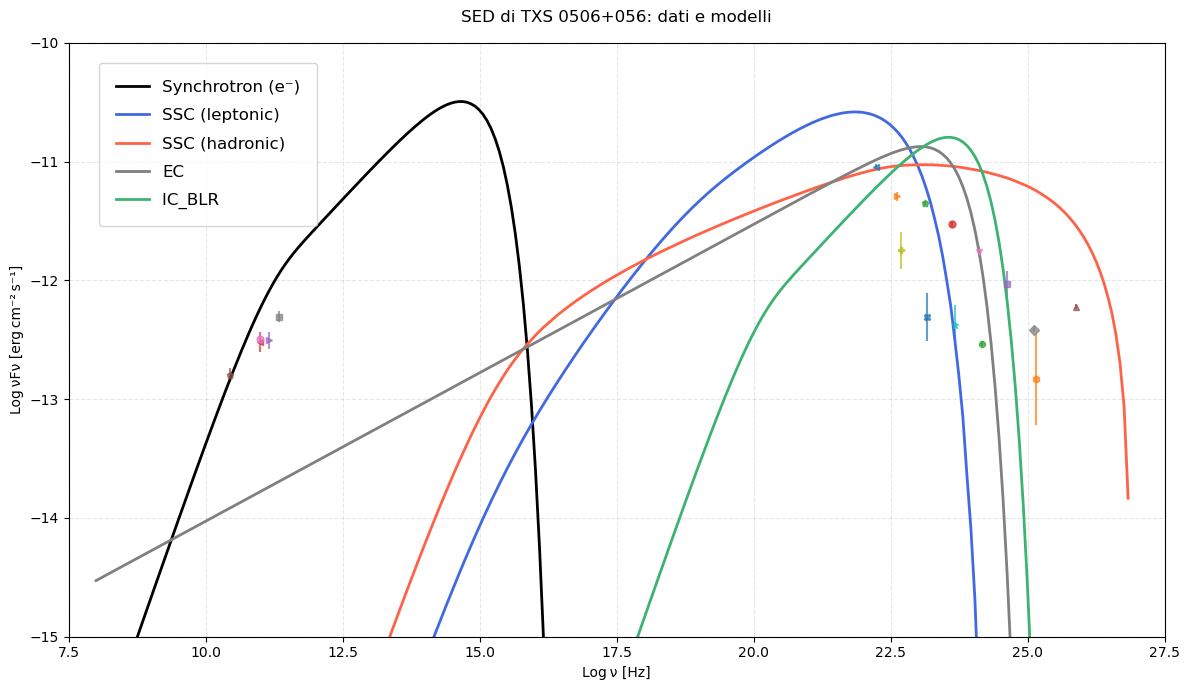

In [145]:

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.constants import m_e, m_p
from astropy.coordinates import Distance
from agnpy.spectra import PowerLaw
from agnpy.emission_regions import Blob
from agnpy.synchrotron import Synchrotron
from agnpy.compton import SynchrotronSelfCompton
from astropy.constants import m_e, m_p, c
from astropy import constants as const
# --- 1) Parametri generali e sorgente ---
source_name = "TXS 0506+056"

R_b    =3.1e16 * u.cm    # raggio del blob  #se aqumento Rbcurva rossa scende
deltaD = 10               # Doppler factor
Gamma  = 19               # bulk Lorentz factor
B      = 0.85 * u.G        # campo magnetico
z      = 0.3365            # redshift
d_L    = Distance(z=z).to(u.cm)
V_b    = (4/3) * np.pi * R_b**3
# --- 2) Blob elettronico (Synch + SSC leptonic) ---
W_e = 0.4e49 * u.erg
n_e = PowerLaw.from_total_energy(
    W=W_e, V=V_b, p=2,
    gamma_min=0.7e2, gamma_max=0.7e4,
    mass=m_e
)
blob_e = Blob(R_b, z, deltaD, Gamma, B, n_e)

# --- 3) Blob protonico (SSC hadronic) ---
W_p = 0.95e52 * u.erg
n_p = PowerLaw.from_total_energy(
    W=W_p, V=V_b, p=2.8,
    gamma_min=0.7e2, gamma_max=8.2e5,
    mass=m_p
)
blob_p = Blob(R_b, z, deltaD, Gamma, B, n_p)
# --- 4) Griglia di frequenze comune ---
nu = np.logspace(8, 30, 300) * u.Hz

# --- 5) Calcolo delle SED teoriche ---
sed_syn   = Synchrotron(blob_e).sed_flux(nu)
sed_ssc   = SynchrotronSelfCompton(blob_e).sed_flux(nu)
sed_ssc_p = SynchrotronSelfCompton(blob_p).sed_flux(nu)  # SSC hadronic

# --- 6) Plot combinato dati + modelli ---
fig, ax = plt.subplots(figsize=(12, 7))

# 6a) dati osservati
for tel, grp in sed_data_valid.groupby('Telescope'):
    m = next(marker_cycle)
    ax.errorbar(
        grp['log_Freq'], grp['log_Flux'],
        yerr=grp['log_Flux_err'],
        fmt=m, ms=5, alpha=0.7,
        linestyle='None', label=tel
    )




#PER INV COMPT
#L_disk = 1e39 * u.erg / u.s ################################## CAMBIA QUE
L_disk = 0.75e40 * u.erg / u.s ################################## CAMBIA QUE  #serve ad abbassare ed alzare
xi     = 0.05                  # frazione che va nella BLR
L_blr  = xi * L_disk

#R_blr  = 2e14 * u.cm ######################################## CAMBIA QUE
R_blr  = 5e15 * u.cm ######################################## CAMBIA QUE

# --- Calcolo densità energetica BLR nel sistema comovente ---
U_rad = (Gamma**2 * L_blr / (4 * np.pi * R_blr**2 * const.c)).to(u.erg / u.cm**3)

# --- Densità energetica del campo magnetico ---
B_cgs = B.to(u.Gauss)  # Assicura che il campo sia in Gauss
U_B = (B_cgs**2 / (8 * np.pi)) * u.erg / u.cm**3
# --- Rapporto luminosità IC-BLR / Synchrotron ---
boost = (U_rad / U_B).value

# --- Shift in frequenza tra Synchrotron e IC-BLR ---
freq_ratio = 0.8e9
nu_shifted = nu / freq_ratio

# Interpoliamo la curva synchrotron al nuovo dominio spostato
from scipy.interpolate import interp1d
syn_interp = interp1d(nu.value, sed_syn.value, bounds_error=False, fill_value=0)
sed_ic_blr_manual = boost * syn_interp(nu_shifted.value) * u.Unit('erg / (s cm2)')

# 6b) maschere di positività
mask_syn = sed_syn.value   > 0
mask_lep = sed_ssc.value   > 0
mask_had = sed_ssc_p.value > 0
mask_ec  = sed_ec.value    > 0
# Curva teorica IC-BLR "manuale"
mask_ic_blr = sed_ic_blr_manual.value > 0



# 6c) curve teoriche (in log10)
l_syn, = ax.plot(np.log10(nu[mask_syn].value),
        np.log10(sed_syn[mask_syn].value),
        '-', lw=2, color='k', label='Synchrotron (e⁻)')

l_lep, = ax.plot(np.log10(nu[mask_lep].value),
        np.log10(sed_ssc[mask_lep].value),
        '-', lw=2, color='royalblue', label='SSC (leptonic)')

l_had, = ax.plot(np.log10(nu[mask_had].value),
        np.log10(sed_ssc_p[mask_had].value),
        '-', lw=2, color='tomato', label='SSC (hadronic)')

l_ec, = ax.plot(np.log10(nu[mask_ec].value),
        np.log10(sed_ec[mask_ec].value),
        '-', lw=2, color='gray', label='EC')

l_ic_blr_manual, = ax.plot(np.log10(nu[mask_ic_blr].value),
        np.log10(sed_ic_blr_manual[mask_ic_blr].value),
        '-', lw=2, color='mediumseagreen', label='IC_BLR ')



# 6d) abbellimenti
ax.set_xlabel('Log ν [Hz]')
ax.set_ylabel('Log νFν [erg cm⁻² s⁻¹]')
ax.set_title(f'SED di {source_name}: dati e modelli', pad=15)

ax.grid(True, which='both', ls='--', alpha=0.3)
ax.set_xlim(7.5, 27.5)
ax.set_ylim(-15, -10)

ax.legend(
    handles=[l_syn, l_lep, l_had, l_ec, l_ic_blr_manual],   # le tue curve
    loc='upper left',                     # angolo in alto a sinistra
    bbox_to_anchor=(0.02, 0.98),          # piccola distanza dai bordi (0–1 relative all’axes)
    ncol=1,                               # una colonna → orientamento verticale
    fontsize='large',                     # dimensione del testo della legenda
    frameon=True,                         # bordo attorno alla legenda
    borderpad=1.0,                        # padding interno al frame
    labelspacing=0.8                      # distanza verticale tra le etichette
)


#ax.legend(
    #loc='upper center',
    #bbox_to_anchor=(0.5, -0.15),
    #ncol=3, fontsize='small', frameon=True
#)

fig.subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.show()


In [146]:
# Converti in F_nu

F_nu_syn = (sed_syn / nu).to("erg cm-2 s-1 Hz-1", equivalencies=u.spectral_density(nu))
F_nu_ssc = (sed_ssc / nu).to("erg cm-2 s-1 Hz-1", equivalencies=u.spectral_density(nu))
F_nu_ssc_p = (sed_ssc_p / nu).to("erg cm-2 s-1 Hz-1", equivalencies=u.spectral_density(nu))

# Maschere per sincrotrone e Compton
mask_syn = nu < 1e22 * u.Hz
mask_ssc = nu >= 1e22 * u.Hz
mask_ssc_p = nu >= 1e22 * u.Hz


# Integrazione su log10(nu)
log_nu_syn = np.log10(nu[mask_syn].value)
log_nu_ssc = np.log10(nu[mask_ssc].value)
log_nu_ssc_p = np.log10(nu[mask_ssc_p].value)

# Converti distanza in cm PRIMA di elevarla al quadrato!
d_L_cm = d_L.to("cm").value

# Ora puoi calcolare le luminosità correttamente in erg/s
L_s = 4 * np.pi * d_L_cm**2 * np.trapezoid(F_nu_syn[mask_syn], x=log_nu_syn)  * u.erg/u.s
L_c = 4 * np.pi * d_L_cm**2 * np.trapezoid(F_nu_ssc[mask_ssc], x=log_nu_ssc)  * u.erg/u.s
L_ssc_p = 4 * np.pi * d_L_cm**2 * np.trapezoid(F_nu_ssc_p[mask_ssc_p], x=log_nu_ssc_p)  * u.erg/u.s

# Stampa i risultati

print("Luminosità sincrotronica L_s =", L_s, "erg/s")
print("Luminosità Compton leptonica L_ssc =", L_c, "erg/s")
print("Luminosità Compton adronica L_ssc_p =", L_ssc_p, "erg/s")

Luminosità sincrotronica L_s = 6.633713422542686e+33 erg2 / (s cm2) erg/s
Luminosità Compton leptonica L_ssc = 3.040912873918912e+23 erg2 / (s cm2) erg/s
Luminosità Compton adronica L_ssc_p = 1.3597611423667083e+23 erg2 / (s cm2) erg/s


In [147]:
from math import gamma

gamma_min = 0.7e2
gamma_max = 0.5e4
p = 2

# Costanti fisiche
c = 3e10  # cm/s
me = 9.11e-28  # g
e = 4.8e-10  # statcoulomb
sigma_T = 6.65e-25  # cm^2
h = 6.626e-27  # erg·s

# Quantità derivate
V = (4/3) * np.pi * R_b**3  # volume della regione
u_B = B**2 / (8 * np.pi)  # densità di energia del campo magnetico
u_e = W_e / V  # densità di energia elettronica
epsilon = u_e / u_B   # efficienza radiativa
if p == 2:
    K = W_e / (me * c**2 * np.log(gamma_max / gamma_min))
else:
    K = (p - 2) * W_e / (me * c**2 * (gamma_min**(2 - p) - gamma_max**(2 - p)))

#K = (p - 2) * W_e / (me * c**2 * (gamma_min**(2 - p) - gamma_max**(2 - p)))  # costante di normalizzazione
u_syn = u_e * epsilon  # densità di energia della radiazione di sincrotrone

# Frequenza di picco del sincrotrone (elettroni)
#gamma_peak = np.sqrt(gamma_min * gamma_max)
gamma_peak = np.sqrt(gamma_min * gamma_max)* p

#nu_syn = (3/4 / np.pi) * gamma_peak**2 * (e * B) / (me * c)
nu_syn = (2 / (3*np.pi)) * gamma_peak**2 * (e * B*deltaD) / (me * c*(1+z))

# Frequenza di picco SSC (elettroni)
nu_ssc = gamma_peak**2 * nu_syn

# Numero totale di elettroni
N_e = K *(gamma_max**(-p + 1) - gamma_min**(-p + 1)) / (1-p)

# Tempo di raffreddamento sincrotrone
t_syn = (6 * np.pi * me * c) / (sigma_T * B**2 * gamma_peak)

# Rapporto luminosità SSC/Synchrotron
#L_ssc_L_syn = u_syn / u_B

# Stampa risultati
print(f"V = {V:.2e} cm^3")
print(f"gamma_peak := {gamma_peak:.2e} Hz")
print(f"u_B = {u_B:.3f} erg/cm^3")
print(f"u_e = {u_e:.3f} erg/cm^3")
print(f"epsilon = {epsilon:.2f}")
print(f"K = {K:.2e}")
print(f"u_syn = {u_syn:.4f} erg/cm^3")
print(f"nu_syn = {nu_syn:.2e} Hz")
print(f"nu_ssc = {nu_ssc:.2e} Hz")
print(f"N_e = {N_e:.2e}")
print(f"t_syn = {t_syn:.2e} s ({t_syn/3600:.1f} h)")
#print(f"L_ssc / L_syn = {L_ssc_L_syn:.3f}")


V = 1.25e+50 cm3 cm^3
gamma_peak := 1.18e+03 Hz
u_B = 0.029 G2 erg/cm^3
u_e = 0.032 erg / cm3 erg/cm^3
epsilon = 1.12 erg / (G2 cm3)
K = 1.14e+54 erg
u_syn = 0.0357 erg2 / (G2 cm6) erg/cm^3
nu_syn = 3.32e+13 G Hz
nu_ssc = 4.65e+19 G Hz
N_e = 1.61e+52 erg
t_syn = 9.06e+05 1 / G2 s (251.7 1 / G2 h)


In [148]:
gamma_min = 0.7e2
gamma_max = 8.2e5
p = 2.8


# Costanti fisiche
c = 3e10  # cm/s
mp = 1.67e-24  # g
e = 4.8e-10  # statcoulomb
sigma_T = 6.65e-25  # cm^2
h = 6.626e-27  # erg·s
pi = np.pi

# Quantità derivate
V = (4/3) * pi * R_b**3
u_p = W_p / V  # densità di energia dei protoni
u_B = B**2 / (8 * pi)  # densità di energia del campo magnetico
epsilon = u_p / u_B # efficienza

# Costante di normalizzazione K_p
K_p = (p - 2) * W_p / (mp * c**2 * (gamma_min**(2 - p) - gamma_max**(2 - p)))

# Frequenza di picco della radiazione di sincrotrone dei protoni
#gamma_p = np.sqrt(gamma_min * gamma_max)
gamma_p = np.sqrt(gamma_min * gamma_max)* p

nu_syn_p = (2 / (3*np.pi)) * gamma_peak**2 * (e * B*deltaD) / (mp * c*(1+z))
# Tempo di raffreddamento per sincrotrone dei protoni
t_syn_p = (6 * pi * mp * c) / (sigma_T * B**2 * gamma_p)

# Stampa risultati
print(f"u_p = {u_p:.2f} erg/cm^3")
print(f"epsilon = {epsilon:.2e}")
print(f"K_p = {K_p:.2e}")
print(f"nu_syn_p = {nu_syn_p:.2e} Hz")
print(f"t_syn_p = {t_syn_p:.2e} s ({t_syn_p/3600:.1f} h)")



u_p = 76.13 erg / cm3 erg/cm^3
epsilon = 2.65e+03 erg / (G2 cm3)
K_p = 1.51e+56 erg
nu_syn_p = 1.81e+10 G Hz
t_syn_p = 9.27e+07 1 / G2 s (25737.3 1 / G2 h)


In [149]:
c = 3e10  # cm/s
pi = np.pi

# Densità di energia radiazione esterna nel sistema comovente
#U_rad_prime = (Gamma**2 * L_disk) / (4 * pi * R_out**2 * c)  #formula corretta ma viene ordine di grandezza molto elevato
U_rad_prime=(Gamma**2)/(12*np.pi)

# Luminosità EC approssimata (proporzionale, senza costanti dimensionali)
L_EC = Gamma**2 * L_disk / R_out**2  # solo per confronto relativo

# Frequenza di picco EC
#nu_ext = 1e15  # Hz, fotoni UV
#gamma = 1e3
#nu_EC = Gamma * Gamma * (4/3) * gamma**2 * nu_ext

print("=== Modello EC ===")
print(f"U'_rad = {U_rad_prime:.2e} erg/cm^3")
print(f"L_EC = {L_EC:.2e}")
#print(f"nu_EC = {nu_EC:.2e} Hz\n")

### === Modello IC-BLR === ###
R_BLR = 1e17 *(L_disk / 1e45)


# Densità di energia BLR nel sistema comovente
U_BLR_prime = (Gamma**2 * L_blr) / (4 * pi * R_BLR**2 * c)

# Rapporto luminosità IC / synchrotron
L_IC = (U_BLR_prime*L_s)/ u_B

nu_IC= (8.8e8 * nu_syn * Gamma) / B

print("=== Modello IC-BLR ===")
print(f"R_BLR  = {R_BLR:.1e} cm")
print(f"U'_BLR = {U_BLR_prime:.2f} erg/cm^3")
print(f"L_IC = {L_IC:.1e}")
print(f"nu_IC = {nu_IC:.2e} Hz")


=== Modello EC ===
U'_rad = 9.58e+00 erg/cm^3
L_EC = 6.77e+37 erg / s
=== Modello IC-BLR ===
R_BLR  = 7.5e+11 erg / s cm
U'_BLR = 638388.16 s / erg erg/cm^3
L_IC = 1.5e+41 erg / (G2 cm2)
nu_IC = 6.53e+23 Hz
